# Research Paper Recommendation System using Natural Language Processing

**Objective**

This project recommends the most relevant research paper based on the user query using semantic search and NLP techniques.

**Features**

• Semantic Search

• Research Paper Recommendation

• AI-based Summary

• Named Entity Recognition

• Keyword Extraction

• Similarity Score Visualization

• Word Cloud

• PDF Report Generation

In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

In [3]:
dataset = load_dataset("CShorten/ML-ArXiv-Papers", split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
print (dataset)

Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [5]:
import pandas as pd

In [6]:
df = pd.DataFrame(dataset)
print(df)

        Unnamed: 0.1  Unnamed: 0  \
0                  0         0.0   
1                  1         1.0   
2                  2         2.0   
3                  3         3.0   
4                  4         4.0   
...              ...         ...   
117587          4995         NaN   
117588          4996         NaN   
117589          4997         NaN   
117590          4998         NaN   
117591          4999         NaN   

                                                    title  \
0                   Learning from compressed observations   
1       Sensor Networks with Random Links: Topology De...   
2       The on-line shortest path problem under partia...   
3         A neural network approach to ordinal regression   
4        Parametric Learning and Monte Carlo Optimization   
...                                                   ...   
117587  Detecting COVID-19 Conspiracy Theories with Tr...   
117588  Fair Feature Subset Selection using Multiobjec...   
117589  A Simple D

In [7]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [8]:
df = df[['title','abstract']]

In [9]:
df


,title,abstract
0,Learning from compressed observations,The problem of statistical learning is to co...
1,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...
...,...,...
117587,Detecting COVID-19 Conspiracy Theories with Tr...,The sharing of fake news and conspiracy theori...
117588,Fair Feature Subset Selection using Multiobjec...,The feature subset selection problem aims at s...
117589,A Simple Duality Proof for Wasserstein Distrib...,We present a short and elementary proof of the...
117590,Combined Learning of Neural Network Weights fo...,"We introduce CoLN, Combined Learning of Neural..."


In [10]:
df.shape

(117592, 2)

In [11]:
df = df.head(15000)

In [12]:
df.shape

(15000, 2)

In [13]:
df.isnull().sum()

,0
title,0
abstract,0


In [14]:
df["paper_text"] = df['title']+" "+df['abstract']

/tmp/ipykernel_5807/2181642906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"] = df['title']+" "+df['abstract']


In [15]:
df[['paper_text']].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


In [16]:
type(df[['paper_text']])

pandas.core.frame.DataFrame

In [17]:
print(df['paper_text'].iloc[0])

Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random
variable $Y$ as a function of a related random variable $X$ on the basis of an
i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable
predictors are drawn from some specified class, and the goal is to approach
asymptotically the performance (expected loss) of the best predictor in the
class. We consider the setting in which one has perfect observation of the
$X$-part of the sample, while the $Y$-part has to be communicated at some
finite bit rate. The encoding of the $Y$-values is allowed to depend on the
$X$-values. Under suitable regularity conditions on the admissible predictors,
the underlying family of probability distributions and the loss function, we
give an information-theoretic characterization of achievable predictor
performance in terms of conditional distortion-rate functions. The ideas are
illustrated on the example of nonparametric regress

In [18]:
from sentence_transformers import SentenceTransformer

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [19]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [20]:
print(type(model))

<class 'sentence_transformers.sentence_transformer.model.SentenceTransformer'>


In [21]:
df["paper_text"]=df["paper_text"].str.replace("\n"," ",regex=False)
df["paper_text"]=df["paper_text"].str.strip()

/tmp/ipykernel_5807/2190359946.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"]=df["paper_text"].str.replace("\n"," ",regex=False)
/tmp/ipykernel_5807/2190359946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["paper_text"]=df["paper_text"].str.strip()


In [22]:
sample_text=df["paper_text"].iloc[0]
sample_text

'Learning from compressed observations   The problem of statistical learning is to construct a predictor of a random variable $Y$ as a function of a related random variable $X$ on the basis of an i.i.d. training sample from the joint distribution of $(X,Y)$. Allowable predictors are drawn from some specified class, and the goal is to approach asymptotically the performance (expected loss) of the best predictor in the class. We consider the setting in which one has perfect observation of the $X$-part of the sample, while the $Y$-part has to be communicated at some finite bit rate. The encoding of the $Y$-values is allowed to depend on the $X$-values. Under suitable regularity conditions on the admissible predictors, the underlying family of probability distributions and the loss function, we give an information-theoretic characterization of achievable predictor performance in terms of conditional distortion-rate functions. The ideas are illustrated on the example of nonparametric regres

In [23]:
embedding = model.encode(sample_text)
print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [24]:
embedding[:56]

array([-0.1315641 , -0.00678266, -0.00367612,  0.03265158,  0.11219642,
        0.01227267,  0.09816719, -0.0900523 ,  0.04231161, -0.01977348,
       -0.03308417,  0.07452948,  0.10632038, -0.02060429, -0.02052106,
        0.00169493,  0.07081953,  0.05854454, -0.11231912,  0.02082474,
        0.05692544,  0.0201578 ,  0.0258311 ,  0.0321703 ,  0.10513764,
       -0.09676763,  0.02700802, -0.0234509 , -0.04549678, -0.01013699,
       -0.01794855, -0.04814427,  0.01077652, -0.03759069,  0.01943481,
        0.03715189,  0.02967844,  0.04330941,  0.04373213,  0.03704866,
       -0.00182594,  0.00455183, -0.00799067,  0.03037368, -0.014378  ,
        0.03795147,  0.0595916 , -0.02583356, -0.06521576,  0.05900268,
       -0.02107134,  0.07359422, -0.05720106,  0.00294061,  0.00767515,
       -0.0333416 ], dtype=float32)

In [25]:
sample_embedding = model.encode(df["paper_text"].head(5).to_list())

In [26]:
print(sample_embedding.shape)

(5, 384)


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

In [28]:
similarity = cosine_similarity(sample_embedding[0].reshape(1,-1), sample_embedding[1].reshape(1,-1))
print(similarity)

[[0.36625272]]


In [29]:
for i in range (1,5):
  similarity = cosine_similarity(sample_embedding[0].reshape(1,-1), sample_embedding[i].reshape(1,-1))
  print(similarity)

[[0.36625272]]
[[0.33522844]]
[[0.15505108]]
[[0.37421533]]


Generating Full embedding for whole 15000


In [30]:
import os
import numpy as np
if os.path.exists("paper_embeddings.npy"):
    print("Loading saved embeddings")
    embedding = np.load("paper_embeddings.npy")
else:
    print("Generating embeddings")
    embedding = model.encode(
        df["paper_text"].tolist(),
        batch_size=32,
        show_progress_bar=True
    )
    np.save("paper_embeddings.npy", embedding)
    print("Embeddings saved successfully!")

Loading saved embeddings


In [31]:
print(embedding.shape)
print(type(embedding))

(15000, 384)
<class 'numpy.ndarray'>


In [32]:
embedding.dtype

dtype('float32')

In [33]:
!pip install faiss-cpu

In [34]:
import faiss

In [35]:
if os.path.exists("paper_faiss.index"):
    print("Loading existing FAISS index")
    index = faiss.read_index("paper_faiss.index")
else:
    print("Creating new FAISS index")
    faiss.normalize_L2(embedding)
    index = faiss.IndexFlatIP(384)
    index.add(embedding)

Creating new FAISS index


In [36]:
print(index.ntotal)

15000


In [37]:
query = "deep learning for medical image analysis"
query_embedding=model.encode([query])
query_embedding.shape

(1, 384)

In [38]:
faiss.normalize_L2(query_embedding)

In [39]:
D,I = index.search(query_embedding , 5)
print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [40]:
print(df.iloc[10466]["title"])

A Perspective on Deep Imaging


In [41]:
print(df.iloc[10466]["abstract"])

  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance in clinical and
preclinical applications. To realize the full impact of machine learning on
medical imaging, major challenges must be addressed.



In [42]:
print(df.iloc[11873]["title"])

Classification of MRI data using Deep Learning and Gaussian
  Process-based Model Selection


In [43]:
def search_paper(query , k=5):
   query_embedding= model.encode([query])
   faiss.normalize_L2(query_embedding)
   D,I = index.search(query_embedding , k)
   return D,I

In [44]:
D,I = search_paper("deep learning for medical image analysis")
print(D)
print(I)

[[0.6807244  0.67092204 0.65219975 0.62811744 0.61311525]]
[[10466 13730 11873 12691 11282]]


In [45]:
def search_paper(query , k=5):
   query_embedding= model.encode([query])
   faiss.normalize_L2(query_embedding)
   D,I = index.search(query_embedding , k)
   return D,I

In [46]:
!pip install transformers==4.46.3

In [47]:
from  transformers import  pipeline
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [48]:
type(summarizer)

transformers.pipelines.text2text_generation.SummarizationPipeline

In [49]:
summary=summarizer(df.iloc[10466]["abstract"],max_length=120,min_length=40)
print(summary)

[{'summary_text': 'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'}]


In [50]:
type(summary)

list

In [51]:
type(summary[0])

dict

In [52]:
summary[0]["summary_text"]

'The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.'

Keybert

In [53]:
def search_and_summarize(query , k=5):
   query_embedding= model.encode([query])
   faiss.normalize_L2(query_embedding)
   D,I = index.search(query_embedding,k)
   for score,idx in zip(D[0], I[0]):
      print("Similarity score", score)
      print("Title",df.iloc[idx]["title"])
      console.print(Panel(df.iloc[idx]["abstract"][:500],
                    title="Abstract",
                    border_style="yellow"))
      summary=summarizer(df.iloc[idx]["abstract"],max_length=120,min_length=40 , do_sample = False)
      print(summary)
      console.print(Panel(summary[0]["summary_text"],
                    title="AI Generated Summary",
                    border_style="green"))

In [54]:
pip install keybert==0.8.5

In [55]:
from keybert import KeyBERT

In [56]:
kw_model = KeyBERT(model) #Pass the model we using orelse it will take the default that is want so for no confusion pass the model

In [57]:
type(kw_model)

keybert._model.KeyBERT

In [58]:
text = df.iloc[10466]["abstract"]
keyword = kw_model.extract_keywords(text)
print(keyword)

[('imaging', 0.4528), ('tomographic', 0.4488), ('reconstruction', 0.3623), ('deep', 0.3003), ('learning', 0.2622)]


In [59]:
print(type(keyword))
print(type(keyword[0]))

<class 'list'>
<class 'tuple'>


In [60]:
keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 3), stop_words="english")

In [61]:
print(keywords)

[('tomographic imaging deep', 0.6704), ('imaging deep learning', 0.6543), ('learning medical imaging', 0.6041), ('imaging deep', 0.5919), ('medical imaging', 0.5281)]


# **NAMED ENTITY RECOGNITION**

In [62]:
def search_and_summarize(query, k=5):

    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)

    D, I = index.search(query_embedding, k)

    best_idx = I[0][0]
    best_score = D[0][0]

    score = best_score
    idx = best_idx

    console.print(
        Panel.fit(
            f"""
 TOP RECOMMENDED PAPER

Title :
{df.iloc[idx]["title"]}

Similarity Score :
{score:.4f}
""",
            title="Top Recommended Paper",
            border_style="bright_green"
        )
    )

    print("Research Abstract")
    print(df.iloc[idx]["abstract"][:500])
    print()

    summary = summarizer(
        df.iloc[idx]["abstract"],
        max_length=120,
        min_length=40,
        do_sample=False
    )

    console.print(
        Panel(
            summary[0]["summary_text"],
            title="AI Generated Summary",
            border_style="green"
        )
    )

    print()

    # -----------------------------
    # Named Entity Recognition
    # -----------------------------

    entities = extract_entities(summary[0]["summary_text"])

    print("=" * 60)
    print("Detected Named Entities")
    print("=" * 60)

    if len(entities) == 0:
        print("No Named Entities Found")
    else:
        for entity, label in entities:
            print(f"{entity:<30} | {label}")

    print()

    # -----------------------------
    # Keyword Extraction
    # -----------------------------

    text = summary[0]["summary_text"]

    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3),
        stop_words="english"
    )

    table = RichTable(title="🏷 Extracted Keywords")

    table.add_column("Keyword", style="cyan")
    table.add_column("Score", style="green")

    for kword, score in keywords:
        table.add_row(kword, f"{score:.3f}")

    print("Top Important Keywords")

    # -----------------------------
    # Similarity Score Graph
    # -----------------------------

    import matplotlib.pyplot as plt

    paper_no = list(range(1, len(D[0]) + 1))
    scores = D[0]

    plt.figure(figsize=(8, 5))

    plt.bar(
        paper_no,
        scores,
        color="skyblue",
        edgecolor="black"
    )

    plt.xlabel("Paper Rank")
    plt.ylabel("Similarity Score")
    plt.title("Similarity Analysis of Recommended Papers")

    plt.xticks(paper_no)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    for i, s in enumerate(scores):
        plt.text(
            i + 1,
            s + 0.003,
            f"{s:.2f}",
            ha="center"
        )
    plt.tight_layout()
    plt.savefig("similarity_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.close()
    print("\n")
    print("="*80)
    print("\n")

    # -----------------------------
    # Word Cloud
    # -----------------------------

    from wordcloud import WordCloud

    word_text = " ".join([k for k, s in keywords])

    wc = WordCloud(
        width=900,
        height=450,
        background_color="white",
        colormap="viridis"
    ).generate(word_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Most Relevant Keywords")
    plt.savefig("wordcloud.png", dpi=300, bbox_inches="tight")
    plt.show()

    export_pdf(
    query,
    df.iloc[idx]["title"],
    best_score,
    df.iloc[idx]["abstract"],
    summary[0]["summary_text"],
    entities,
    keywords
)

In [63]:
!pip install spacy

In [64]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [65]:
import spacy

ner_model = spacy.load("en_core_web_sm")

print("NER Model Loaded Successfully")

NER Model Loaded Successfully


In [66]:
def extract_entities(text):

    doc = ner_model(text)

    entities = []

    for ent in doc.ents:
        entities.append((ent.text, ent.label_))

    return entities

In [67]:
sample = """
Google developed BERT using PyTorch in California.
Microsoft released GPT.
Research was conducted in India.
"""

print(extract_entities(sample))

[('Google', 'ORG'), ('BERT', 'ORG'), ('PyTorch', 'ORG'), ('California', 'GPE'), ('Microsoft', 'ORG'), ('GPT', 'ORG'), ('India', 'GPE')]


In [68]:
!pip install rich

In [69]:
from rich.console import Console
from rich.panel import Panel
from rich.table import Table as RichTable

console = Console()

print("Rich Loaded Successfully")

Rich Loaded Successfully


In [70]:
!pip install wordcloud

In [71]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("WordCloud Loaded Successfully")

WordCloud Loaded Successfully


In [72]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.9 MB/s eta 0:00:00


In [73]:
from rich.console import Console
from rich.panel import Panel
from rich.table import Table as RichTable

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    Table as PDFTable,
    TableStyle
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER
from reportlab.lib import colors
from reportlab.lib.units import inch

def export_pdf(query,title,score,abstract,summary,entities,keywords):

    styles = getSampleStyleSheet()

    title_style = styles["Heading1"]
    title_style.alignment = TA_CENTER

    heading = styles["Heading2"]
    normal = styles["BodyText"]

    safe_query = query.replace(" ", "_")

    doc = SimpleDocTemplate(
    f"Research_Report_{safe_query}.pdf")

    story = []

    # -------------------------------
    # Title
    # -------------------------------

    story.append(Paragraph("AI-Based Research Paper Recommendation System", title_style))
    story.append(Spacer(1,0.3*inch))

    # -------------------------------
    # Query
    # -------------------------------

    story.append(Paragraph(f"<b>Query :</b> {query}",normal))
    story.append(Spacer(1,0.15*inch))

    # -------------------------------
    # Title
    # -------------------------------

    story.append(Paragraph("<b>Recommended Research Paper</b>",heading))
    story.append(Paragraph(title,normal))
    story.append(Spacer(1,0.15*inch))

    # -------------------------------
    # Similarity
    # -------------------------------

    story.append(
        Paragraph(
            f"<b>Similarity Score :</b> {score:.4f}",
            normal
        )
    )

    story.append(Spacer(1,0.25*inch))

    # -------------------------------
    # Abstract
    # -------------------------------

    story.append(Paragraph("Abstract",heading))
    story.append(Paragraph(abstract,normal))
    story.append(Spacer(1,0.25*inch))

    # -------------------------------
    # AI Summary
    # -------------------------------

    story.append(Paragraph("Generated Summary",heading))
    story.append(Paragraph(summary,normal))
    story.append(Spacer(1,0.25*inch))

    # -------------------------------
    # Named Entities
    # -------------------------------

    story.append(Paragraph("Detected Named Entities",heading))

    if len(entities)==0:

        story.append(
            Paragraph(
                "No Named Entities Found",
                normal
            )
        )

    else:

        data=[["Entity","Label"]]

        for e,l in entities:
            data.append([e,l])

        table = PDFTable(data,colWidths=[3*inch,2*inch])

        table.setStyle(
            TableStyle([
                ("BACKGROUND",(0,0),(-1,0),colors.darkblue),
                ("TEXTCOLOR",(0,0),(-1,0),colors.white),
                ("GRID",(0,0),(-1,-1),1,colors.black),
                ("BACKGROUND",(0,1),(-1,-1),colors.beige),
                ("ALIGN",(0,0),(-1,-1),"CENTER"),
                ("BOTTOMPADDING",(0,0),(-1,0),8),
            ])
        )

        story.append(table)

    story.append(Spacer(1,0.3*inch))

    # -------------------------------
    # Keywords
    # -------------------------------

    story.append(Paragraph("Important Keywords",heading))

    keyword_data=[["Keyword","Score"]]

    for k,s in keywords:
        keyword_data.append(
            [
                k,
                f"{s:.3f}"
            ]
        )

    keyword_table = PDFTable(
        keyword_data,
        colWidths=[4.5*inch,1*inch]
    )

    keyword_table.setStyle(
        TableStyle([
            ("BACKGROUND",(0,0),(-1,0),colors.green),
            ("TEXTCOLOR",(0,0),(-1,0),colors.white),
            ("GRID",(0,0),(-1,-1),1,colors.black),
            ("BACKGROUND",(0,1),(-1,-1),colors.whitesmoke),
            ("ALIGN",(0,0),(-1,-1),"CENTER"),
            ("BOTTOMPADDING",(0,0),(-1,0),8),
        ])
    )

    story.append(keyword_table)

    story.append(Spacer(1,0.35*inch))

    # -------------------------------
    # Similarity Score Graph
    # -------------------------------

    story.append(Paragraph("Similarity Score Analysis", heading))
    story.append(Spacer(1,0.15*inch))

    try:
        graph = Image("similarity_graph.png")
        graph.drawWidth = 6.2 * inch
        graph.drawHeight = 3.8 * inch
        story.append(graph)
    except:
        story.append(Paragraph("Graph image not found.", normal))

    story.append(Spacer(1,0.30*inch))

    # -------------------------------
    # Word Cloud
    # -------------------------------

    story.append(Paragraph("Keyword Distribution", heading))
    story.append(Spacer(1,0.15*inch))

    try:
        cloud = Image("wordcloud.png")
        cloud.drawWidth = 6.2 * inch
        cloud.drawHeight = 3.8 * inch
        story.append(cloud)
    except:
        story.append(Paragraph("WordCloud image not found.", normal))

    story.append(Spacer(1,0.30*inch))

    # -------------------------------
    # Footer
    # -------------------------------

    story.append(
        Paragraph(
            "<font size=9 color=grey>"
            "Generated using AI Research Paper Recommendation System"
            "Developed by Soham Mahure"
            "</font>",
            normal
        )
    )

    # -------------------------------
    # Build PDF
    # -------------------------------

    doc.build(story)

    print("-"*60)
    print("PDF Generated Successfully")
    print("File Name : Research_Report.pdf")
    print("-"*60)

In [74]:
search_paper("deep learning for medical image analysis")

(array([[0.6807244 , 0.67092204, 0.65219975, 0.62811744, 0.61311525]],
       dtype=float32),
 array([[10466, 13730, 11873, 12691, 11282]]))

╭──── Top Recommended Paper ────╮
│                               │
│  TOP RECOMMENDED PAPER        │
│                               │
│ Title :                       │
│ A Perspective on Deep Imaging │
│                               │
│ Similarity Score :            │
│ 0.7355                        │
│                               │
╰───────────────────────────────╯

Research Abstract
  The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance



╭───────────────────────────────────────────── AI Generated Summary ──────────────────────────────────────────────╮
│ The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only     │
│ image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain   │
│ knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical    │
│ applications.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Detected Named Entities
No Named Entities Found

Top Important Keywords


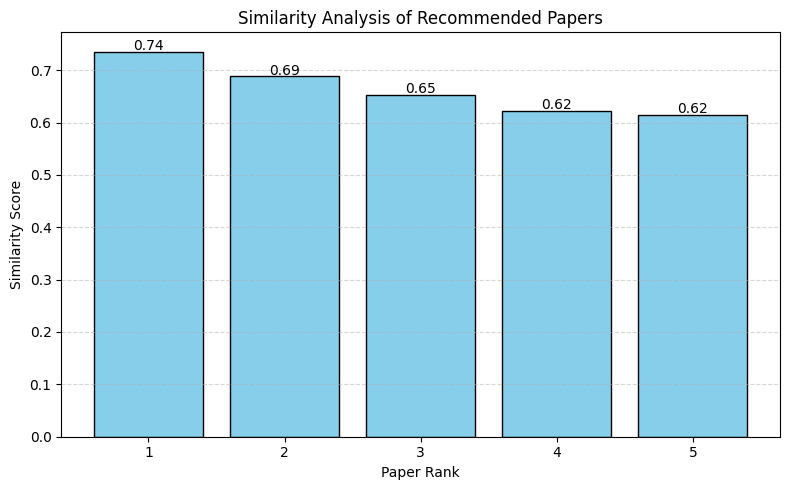

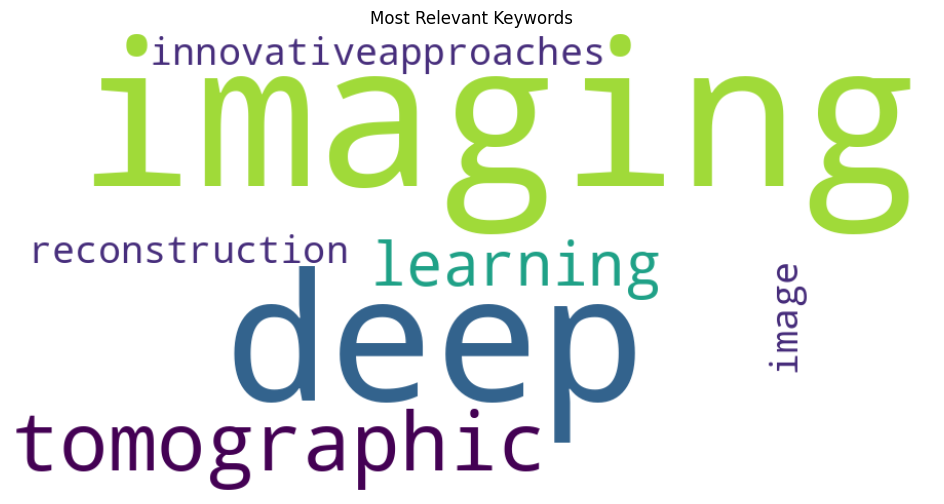

------------------------------------------------------------
PDF Generated Successfully
File Name : Research_Report.pdf
------------------------------------------------------------


In [75]:
search_and_summarize("Deep learning in medical imaging" , k = 5 )

╭─────────────────────── Top Recommended Paper ────────────────────────╮
│                                                                      │
│  TOP RECOMMENDED PAPER                                               │
│                                                                      │
│ Title :                                                              │
│ Implementation of deep learning algorithm for automatic detection of │
│   brain tumors using intraoperative IR-thermal mapping data          │
│                                                                      │
│ Similarity Score :                                                   │
│ 0.6452                                                               │
│                                                                      │
╰──────────────────────────────────────────────────────────────────────╯

Research Abstract
  The efficiency of deep machine learning for automatic delineation of tumor
areas has been demonstrated for intraoperative neuronavigation using active
IR-mapping with the use of the cold test. The proposed approach employs a
matrix IR-imager to remotely register the space-time distribution of surface
temperature pattern, which is determined by the dynamics of local cerebral
blood flow. The advantages of this technique are non-invasiveness, zero risks
for the health of patients and medical staf



╭───────────────────────────────────────────── AI Generated Summary ──────────────────────────────────────────────╮
│ The efficiency of deep machine learning has been demonstrated for intraoperative neuronavigation using          │
│ activeIR-mapping with the use of the cold test. The advantages of this technique are non-invasiveness, zero     │
│ risks for health of patients and medical staff, low implementation and operational costs, ease and speed of     │
│ use.                                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Detected Named Entities
activeIR                       | ORG
zero                           | CARDINAL

Top Important Keywords


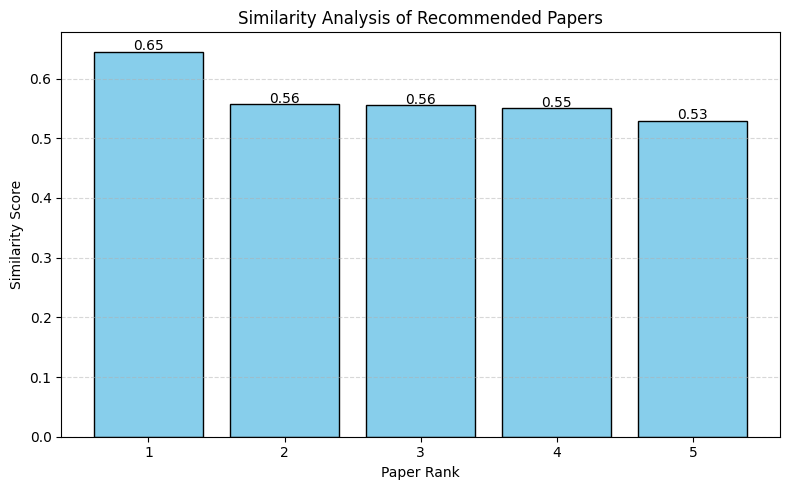

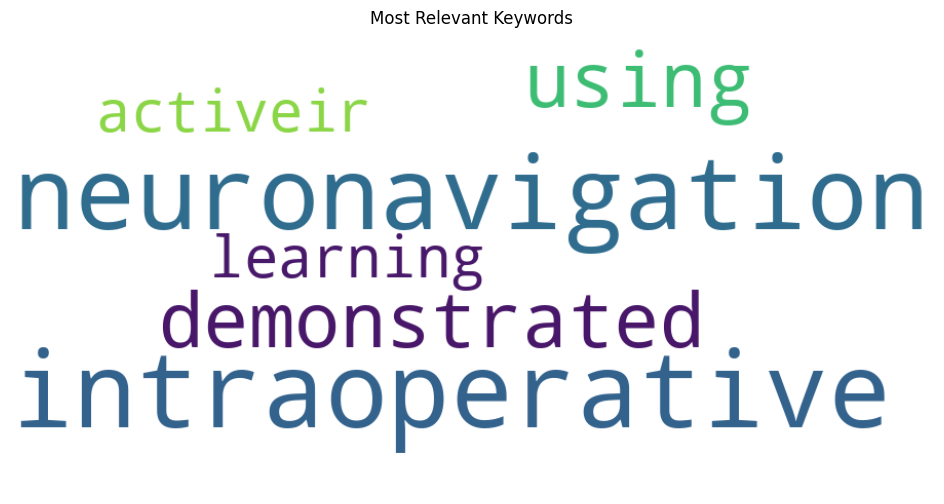

------------------------------------------------------------
PDF Generated Successfully
File Name : Research_Report.pdf
------------------------------------------------------------


In [76]:
search_and_summarize("Brain Tumor Detection using Deep Learning", k=5)

╭───────────────── Top Recommended Paper ──────────────────╮
│                                                          │
│  TOP RECOMMENDED PAPER                                   │
│                                                          │
│ Title :                                                  │
│ Automatic Breast Ultrasound Image Segmentation: A Survey │
│                                                          │
│ Similarity Score :                                       │
│ 0.5632                                                   │
│                                                          │
╰──────────────────────────────────────────────────────────╯

Research Abstract
  Breast cancer is one of the leading causes of cancer death among women
worldwide. In clinical routine, automatic breast ultrasound (BUS) image
segmentation is very challenging and essential for cancer diagnosis and
treatment planning. Many BUS segmentation approaches have been studied in the
last two decades, and have been proved to be effective on private datasets.
Currently, the advancement of BUS image segmentation seems to meet its
bottleneck. The improvement of the performance is increasi



╭───────────────────────────────────────────── AI Generated Summary ──────────────────────────────────────────────╮
│ Breast cancer is one of the leading causes of cancer death among women worldwide. In clinical routine,          │
│ automatic breast ultrasound (BUS) image segmentation is very challenging and essential for cancer diagnosis.    │
│ Many BUS segmentation approaches have been studied in the last two decades.                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


Detected Named Entities
Breast                         | ORG
the last two decades           | DATE

Top Important Keywords


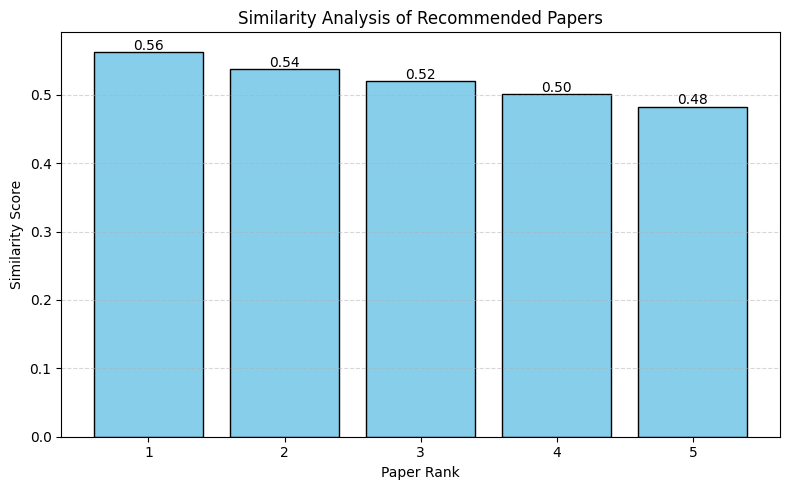

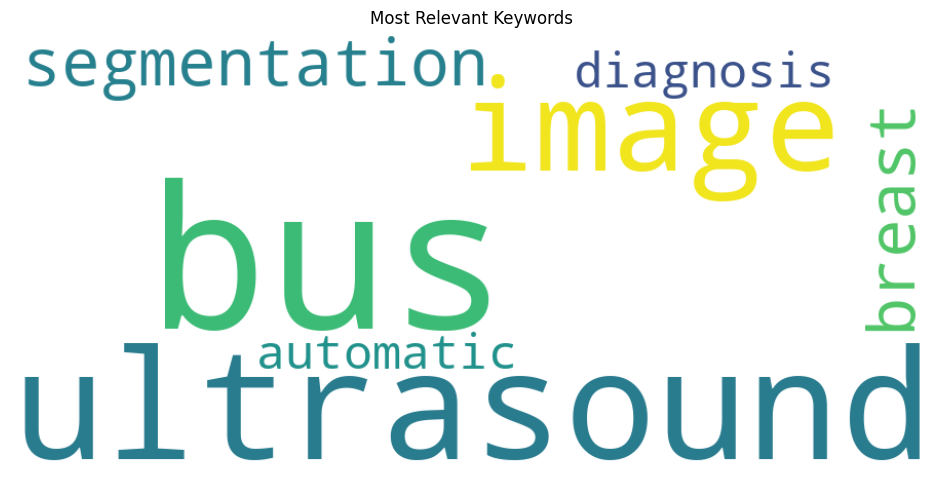

------------------------------------------------------------
PDF Generated Successfully
File Name : Research_Report.pdf
------------------------------------------------------------


In [77]:
search_and_summarize("Medical Image Segmentation", k=5)